# Comparison between Early Mesoderm populations

In [1]:
here::i_am("revisions/02_EarlyMes_comparison/celltype_similarity.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

suppressPackageStartupMessages(library(scran))
suppressPackageStartupMessages(library(scater))
suppressPackageStartupMessages(library(Seurat))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(edgeR))


BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers = 16

# Multi core using future - built in to seurat
plan("multicore", workers = 16)
options(future.globals.maxSize = 50 * 1024 ^ 3) # for 50 Gb RAM

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/code

Warning message:
“package ‘rtracklayer’ was built under R version 4.2.3”


In [2]:
args = list()

# Metadata
args$metadata = file.path(io$basedir, 'results/rna_atac/clustering/metadata_celltype_annotated_v2.txt.gz')

# RNA_sce
args$rna_sce = file.path(io$basedir, 'processed/rna/SingleCellExperiment.rds')

args$logFC_thr = 0.25
args$FDR_thr = 0.05

# outdir
args$outdir = file.path(io$basedir, 'results/revisions/02_EarlyMes_comparison/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
# Load meta
meta = fread(args$metadata)[genotype == 'WT']

#### Load Data

In [85]:
# load sce
rna.sce <- load_SingleCellExperiment(args$rna_sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

In [123]:
rna.pb = aggregateAcrossCells(rna.sce, meta$celltype_v2)

In [124]:
rna.pb = logNormCounts(rna.pb)

In [125]:
rna.pb = rna.pb[,c('PGC', opts$celltype_levels2)]

In [126]:
compare_celltypes = function(ct1, ct2){
    tmp = data.table(
        ct1 = ct1,
        ct2 = ct2,
        corr = cor(as.vector(logcounts(rna.pb[, ct1])),
                   as.vector(logcounts(rna.pb[, ct2])))
    )
    
    return(tmp)
}

In [127]:
comparisons = mclapply(colnames(rna.pb), function(x){
    return(lapply(colnames(rna.pb), function(y){
        return(compare_celltypes(x,y))
    }) %>% rbindlist())
}, mc.cores = 12) %>% rbindlist()

Warning message:
“Removed 23 rows containing missing values (`geom_tile()`).”


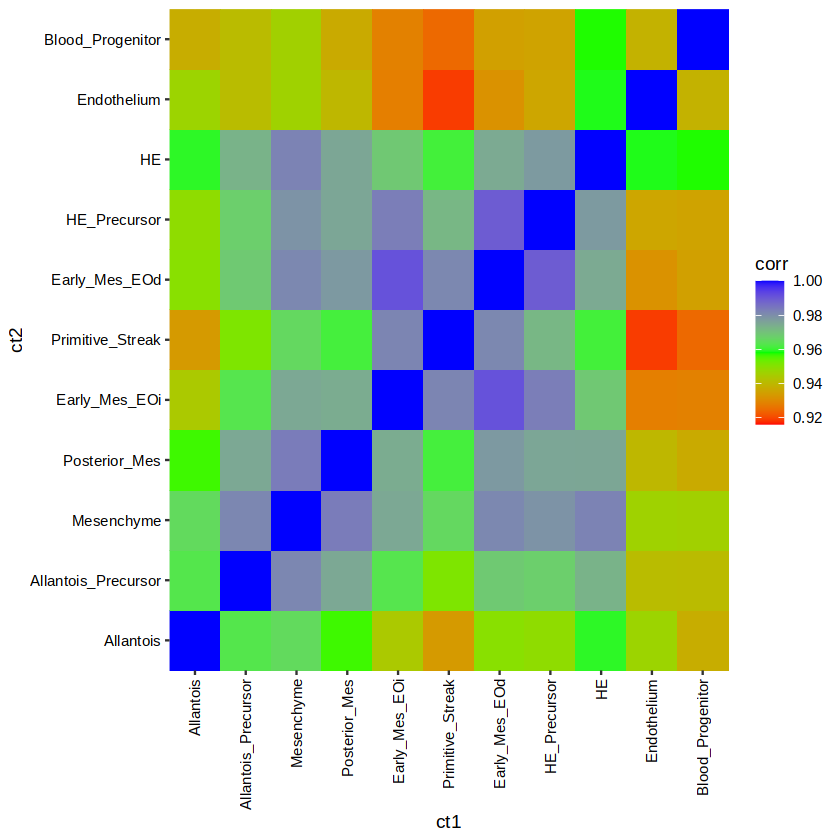

In [129]:
ggplot(comparisons, aes(ct1, ct2, fill = corr)) + 
    geom_tile() + 
    scale_fill_gradientn(colors = rainbow(3)) + 
    scale_x_discrete(limits = opts$celltype_levels2, expand = c(0,0)) + 
    scale_y_discrete(limits = opts$celltype_levels2, expand = c(0,0)) + 
    theme(axis.text = element_text(color = 'black'),
            axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5))

In [186]:
hvgs = VariableFeatures(FindVariableFeatures(as.Seurat(rna.pb), nfeatures = 1000))

In [187]:
rna.pb2 = rna.pb[hvgs,]

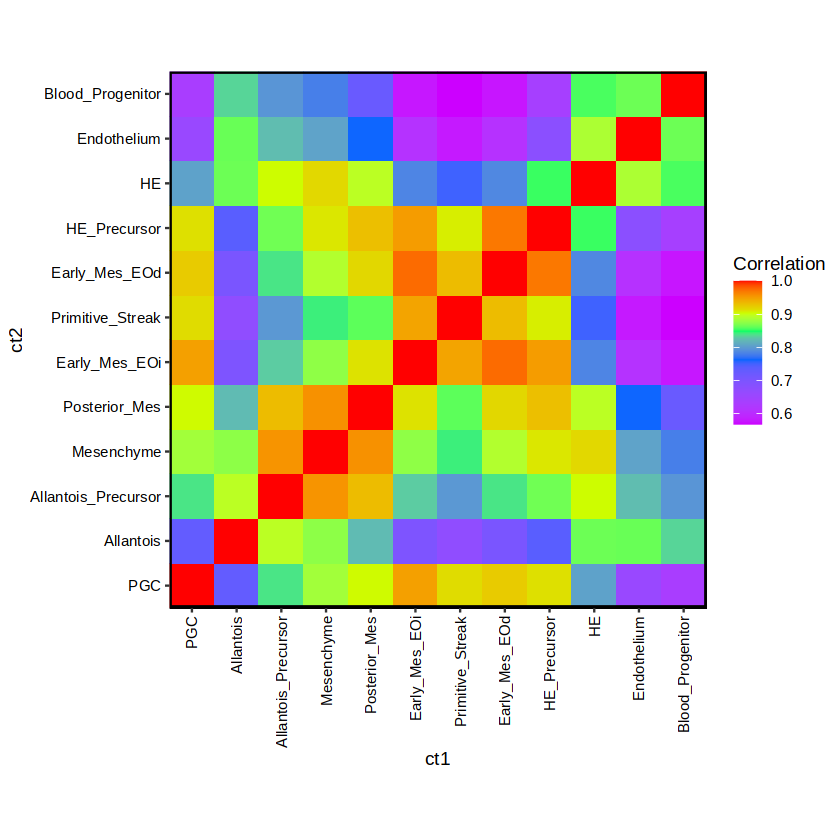

In [218]:
compare_celltypes = function(ct1, ct2){
    tmp = data.table(
        ct1 = ct1,
        ct2 = ct2,
        corr = cor(as.vector(logcounts(rna.pb2[, ct1])),
                   as.vector(logcounts(rna.pb2[, ct2])))
    )
    
    return(tmp)
}

comparisons = mclapply(colnames(rna.pb2), function(x){
    return(lapply(colnames(rna.pb2), function(y){
        return(compare_celltypes(x,y))
    }) %>% rbindlist())
}, mc.cores = 12) %>% rbindlist()

ggplot(comparisons, aes(ct1, ct2, fill = corr)) + 
    geom_tile() + 
    scale_fill_gradientn(colors = rev(rainbow(5)), values = c(0, 0.4, 0.6, 0.7, 0.8, 1), name = 'Correlation') + 
    scale_x_discrete(limits = c('PGC', opts$celltype_levels2), expand = c(0,0)) + 
    scale_y_discrete(limits = c('PGC', opts$celltype_levels2), expand = c(0,0)) +
    coord_fixed() + 
    theme(axis.text = element_text(color = 'black'),
            axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
          panel.border = element_rect(color = 'black', linewidth = 1, fill = NA)
          )